In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [2]:
data = load_iris()
X = data.data

In [3]:
pipelines = {
    'k-mean (k = 3)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KMeans(n_clusters = 3, init = 'k-means++', random_state = 42, n_init = 10))
    ]),

    'Hierarchical (Ward, k=3)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', AgglomerativeClustering(n_clusters = 3, linkage = 'ward'))
    ]),

    'DBSCAN (eps=0.8, min_samples=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DBSCAN(eps = 0.8, min_samples = 5))
    ])
}

In [4]:
results = []

In [5]:
for name, pipe in pipelines.items():
    labels = pipe.fit_predict(X)
    X_scaled = pipe.named_steps['scaler'].transform(X)

    valid_mask = labels != -1
    n_clusters = len(np.unique(labels[valid_mask]))
    n_noise = np.sum(labels == -1)

    if n_clusters > 1:
        sil = silhouette_score(X_scaled[valid_mask], labels[valid_mask])
        ch = calinski_harabasz_score(X_scaled[valid_mask], labels[valid_mask])
        db = davies_bouldin_score(X_scaled[valid_mask], labels[valid_mask])
    else:
        sil, ch, db = np.nan, np.nan, np.nan

    results.append({
        "Pipeline": name,
        "Clusters": n_clusters,
        "Noise Points": n_noise,
        "Silhouette Score (↑)": f"{sil:.4f}" if not np.isnan(sil) else "N/A",
        "Calinski-Harabasz (↑)": f"{ch:.2f}" if not np.isnan(ch) else "N/A",
        "Davies-Bouldin (↓)": f"{db:.4f}" if not np.isnan(db) else "N/A"
    })

In [6]:
metrics_df = pd.DataFrame(results)
print("PIPELINE CLUSTERING EVALUATION RESULTS :")
print(metrics_df.to_string(index=False))

PIPELINE CLUSTERING EVALUATION RESULTS :
                       Pipeline  Clusters  Noise Points Silhouette Score (↑) Calinski-Harabasz (↑) Davies-Bouldin (↓)
                 k-mean (k = 3)         3             0               0.4599                241.90             0.8336
       Hierarchical (Ward, k=3)         3             0               0.4467                222.72             0.8035
DBSCAN (eps=0.8, min_samples=5)         2             4               0.5979                277.65             0.5688


In [7]:
from sklearn.decomposition import PCA

In [8]:
pca_pipelines = {
    'k-mean (k = 3)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components = 2, random_state = 42)),
        ('model', KMeans(n_clusters = 3, init = 'k-means++', random_state = 42, n_init = 10))
    ]),

    'Hierarchical (Ward, k=3)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components = 2)),
        ('model', AgglomerativeClustering(n_clusters = 3, linkage = 'ward'))
    ]),

    'DBSCAN (eps=0.5, min_samples=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components = 2)),
        ('model', DBSCAN(eps = 0.5, min_samples = 5))
    ])
}

In [9]:
pca_results = []
predictions = {}
X_pca_dict = {}

In [10]:
for name, pipe in pca_pipelines.items():
    labels = pipe.fit_predict(X)
    predictions[name] = labels
    
    X_pca = pipe[:-1].transform(X)
    X_pca_dict[name] = X_pca
    
    valid_mask = labels != -1
    n_clusters = len(np.unique(labels[valid_mask]))
    n_noise = np.sum(labels == -1)
    
    if n_clusters > 1:
        sil = silhouette_score(X_pca[valid_mask], labels[valid_mask])
        ch = calinski_harabasz_score(X_pca[valid_mask], labels[valid_mask])
        db = davies_bouldin_score(X_pca[valid_mask], labels[valid_mask])
    else:
        sil, ch, db = np.nan, np.nan, np.nan

    pca_results.append({
        "Pipeline": name,
        "Clusters": n_clusters,
        "Noise Points": n_noise,
        "Silhouette Score (↑)": f"{sil:.4f}" if not np.isnan(sil) else "N/A",
        "Calinski-Harabasz (↑)": f"{ch:.2f}" if not np.isnan(ch) else "N/A",
        "Davies-Bouldin (↓)": f"{db:.4f}" if not np.isnan(db) else "N/A"
    })

In [11]:
metrics_df = pd.DataFrame(pca_results)
print("PCA PIPELINE CLUSTERING EVALUATION :")
print(metrics_df.to_string(index=False))

PCA PIPELINE CLUSTERING EVALUATION :
                       Pipeline  Clusters  Noise Points Silhouette Score (↑) Calinski-Harabasz (↑) Davies-Bouldin (↓)
                 k-mean (k = 3)         3             0               0.5092                293.86             0.7099
       Hierarchical (Ward, k=3)         3             0               0.5111                286.33             0.7054
DBSCAN (eps=0.5, min_samples=5)         2            12               0.6580                370.69             0.4866


In [12]:
import matplotlib.pyplot as plt

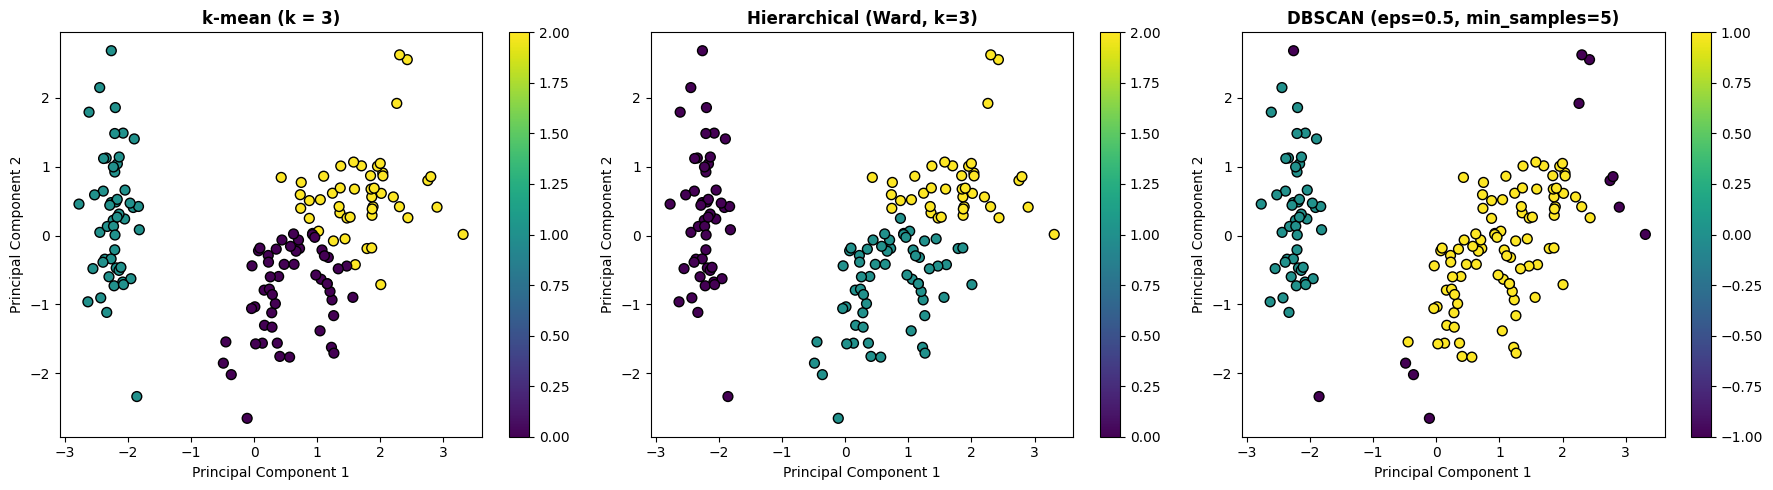

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, labels) in zip(axes, predictions.items()):
    X_pca = X_pca_dict[name]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', edgecolors='k', s=50)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

In [14]:
for name, pipe in pca_pipelines.items():
    print(f'{name} :\n {pipe.named_steps["pca"].components_}\n')

k-mean (k = 3) :
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]

Hierarchical (Ward, k=3) :
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]

DBSCAN (eps=0.5, min_samples=5) :
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]

